***Hello World Agent***


First LangGraph Graph

In [2]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph #StateGraph no small s captial S the it is an framework that helps you design and manage the flow of tasks in your application using an graph 

In [3]:
#Now we create an AgentState-shared data structure that keeps track of information as your application runs.

class AgentState(TypedDict):
    message : str
    
    
def greeting_node(state:AgentState) -> AgentState:
    """ Simple node that adds a greeting message to the state"""
    # state["message"]="Hey "+state["message"]+ " ,how is your day going?"
    state["message"]="Hey "+state["message"]+ " ,you are doing an amazing job"
    
    return state
    
    

In [ ]:
graph = StateGraph(AgentState)

graph.add_node("greeter",greeting_node) #(anyname,functio_name)we should pass here an name(anyname) and action(function we crated above).

graph.set_entry_point("greeter")#we are telling from where to start

graph.set_finish_point("greeter")#the ending point where it need to end

app=graph.compile()

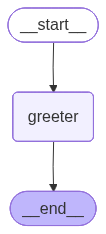

In [5]:
from IPython.display import Image,display
display(Image(app.get_graph().draw_mermaid_png()))

In [6]:
res=app.invoke({"message":"Bob"})


In [7]:
res["message"]

'Hey Bob ,you are doing an amazing job'

****EXERCISES-HW****

In [8]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    name:str
    

def help_node(state:AgentState)->AgentState:
    """Simple helping agent that helps people"""
    state["name"]="Hey "+state["name"]+" ,You are an amazing person"
    
    return state


In [9]:
graph2=StateGraph(AgentState)
graph2.add_node("Helping agent",help_node)
graph2.set_entry_point("Helping agent")
graph2.set_finish_point("Helping agent")
app2=graph2.compile()

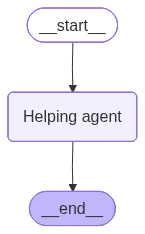

In [10]:
from IPython.display import Image,display
display(Image(app2.get_graph().draw_mermaid_png()))

In [4]:
res2=app2.invoke({"name":"Shiva"})

In [5]:
res2["name"]

'Hey Shiva ,You are an amazing person'

In [ ]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message:str
    

def help_node(state:AgentState)->AgentState:
    """Simple helping agent that helps people"""
    state["message"]="Hey "+state["message"]+" ,what is on your mind today"
    
    return state

graph2=StateGraph(AgentState)
graph2.add_node("Helping agent",help_node)
graph2.set_entry_point("Helping agent")
graph2.set_finish_point("Helping agent")
app2=graph2.compile()

res2=app2.invoke({"message":"Shiva"})
res2["message"]

In [16]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message:str
    
def FAQ(state:AgentState)->AgentState:
    """An smart agent that ask user questions on the RAG"""
    state["message"]="Hey "+state["message"]+ ", what is RAG and why it is used"
    
    return state



In [17]:
g3=StateGraph(AgentState)
g3.add_node("Smart helping agent",FAQ)
g3.set_entry_point("Smart helping agent")
g3.set_finish_point("Smart helping agent")
ap3=g3.compile()

res3=ap3.invoke({"message":"john"})
res3["message"]

'Hey john, what is RAG and why it is used'

In [19]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message:str
    
def ans_node(state:AgentState)->AgentState:
    if state["message"]=="What is RAG":
        state["message"]="RAG Stands for Retrieval Augmented generation"
        
    else:
        state["message"]="AI Stands fro artificial Intelligence"
        
    return state



In [23]:
g4=StateGraph(AgentState)
g4.add_node("Ex-2",ans_node)
g4.set_entry_point("Ex-2")
g4.set_finish_point("Ex-2")
ap4=g4.compile()

res4=ap4.invoke({"message":"What is RAG"})
res4["message"]


'RAG Stands for Retrieval Augmented generation'

In [32]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    message:str
    
def real_FAQ(state:AgentState)->AgentState:
    """An simple real time FAQ Answering system"""
    if state ["message"]=="What is an RAG":
        state["message"]="RAG stands for retrieval augmented generation"
    
    elif state["message"]=="What is ai":
        state["message"]="Ai stands for artificial intelligence"
        
    elif state["message"]=="What is langchain":
        state["message"]="It is an Framwork used to create ai applications"
        
    else:
        state["message"]="I don't know answer"
        
    return state

def smart_FAQ(state: AgentState)->AgentState:
    """ An smart agent that answer the question"""
    if state["message"]=="What is LangGraph":
        state["message"]="It is used to build ai agents"
    else:
        state["message"]="message i dont' know answer"
        
    return state

In [34]:
g5=StateGraph(AgentState)
g5.add_node("real",real_FAQ)
g5.set_entry_point("real")
g5.set_finish_point("real")
ap5=g5.compile()
res5=ap5.invoke({"message":"What is langgraph"})
res5["message"]


"I don't know answer"

In [36]:
g6=StateGraph(AgentState)
g6.add_node("rrr",smart_FAQ)
g6.set_entry_point("rrr")
g6.set_finish_point("rrr")
ap6=g6.compile()
res6=ap6.invoke({"message":"What is LangGraph"})
res6["message"]

'It is used to build ai agents'

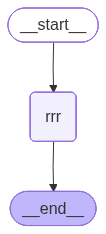

In [37]:
from IPython.display import Image,display
display(Image(ap6.get_graph().draw_mermaid_png()))

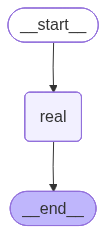

In [30]:
from IPython.display import Image,display
display(Image(ap5.get_graph().draw_mermaid_png()))

In [39]:
from typing import TypedDict
from langgraph.graph import StateGraph
from langchain_google_genai import ChatGoogleGenerativeAI
from dotenv import load_dotenv

load_dotenv()

llm=ChatGoogleGenerativeAI(
    model="gemini-2.5-flash"
)

class AgentState(TypedDict):
    message:str
    

def FAQ_agent(state:AgentState)->AgentState:
    question=state["message"]
    response=llm.invoke(question)
    state["message"]=response.content
    return state


g7=StateGraph(AgentState)
g7.add_node("FAQ",FAQ_agent)
g7.set_entry_point("FAQ")
g7.set_finish_point("FAQ")

ap8=g7.compile()

res=ap8.invoke({
    "message":"what is an RAG"
})
print(res["message"])

Both GOOGLE_API_KEY and GEMINI_API_KEY are set. Using GOOGLE_API_KEY.


**RAG stands for Retrieval-Augmented Generation.**

It's a technique used to improve the output of Large Language Models (LLMs) by giving them access to external, up-to-date, and domain-specific information, rather than relying solely on the knowledge they were trained on.

Think of it like this:

*   **Traditional LLM:** A brilliant student who has read a lot of books, but can only answer questions based on what they remember from those books (which might be outdated or not specific enough).
*   **LLM with RAG:** That same brilliant student, but now they also have access to a library full of *current and relevant books and documents*, and a super-efficient research assistant who can quickly find the exact passages needed to answer any question.

### Why was RAG developed? What problem does it solve?

LLMs, despite their impressive capabilities, have several limitations that RAG addresses:

1.  **Knowledge Cutoff:** LLMs are trained on data up to a certain point in time. They don't kno

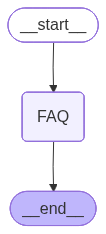

In [40]:
from IPython.display import Image,display
display(Image(ap8.get_graph().draw_mermaid_png()))

In [13]:
from typing import Dict,TypedDict
from langgraph.graph import StateGraph

In [16]:
class AgentState(TypedDict):
    message:str
    

def congrats(state:AgentState)->AgentState:
    """You are an agents that congrats people on the small efforts they put in daily"""
    state["message"]="Hey "+state["message"] +",Today you put in some effort so it supports your growth "
    return state


In [25]:
g7=StateGraph(AgentState)
g7.add_node("Congrats",congrats)
g7.set_entry_point("Congrats")
g7.set_finish_point("Congrats")
rev=g7.compile()


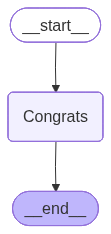

In [29]:
from IPython.display import Image,display
display(Image(rev.get_graph().draw_mermaid_png()))

In [34]:
rev=rev.invoke({"message":"Martin"})

In [35]:
rev

{'message': 'Hey Martin,Today you put in some effort so it supports your growth '}

In [36]:
from typing import TypedDict
from langgraph.graph import StateGraph

In [47]:
class AgentState(TypedDict):
    hero:str
    

def herosection(state:AgentState)->AgentState:
    """You are the description of the hero in this world"""
    state["hero"]="Hello "+ state["hero"] +",welcome to the intative"
    
    return state

    

In [48]:
g8=StateGraph(AgentState)
g8.add_node("desc",herosection)
g8.set_entry_point("desc")
g8.set_finish_point("desc")
ap9=g8.compile()

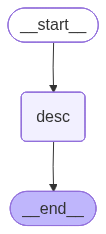

In [49]:
from IPython.display import Image,display
display(Image(ap9.get_graph().draw_mermaid_png()))

In [50]:
depo=ap9.invoke({"hero":"Ironman"})

In [51]:
depo

{'hero': 'Hello Ironman,welcome to the intative'}

In [1]:
print("Hello")

Hello


In [3]:
from typing import TypedDict
from langgraph.graph import StateGraph


In [20]:
class AgentState(TypedDict):
    message:str
    
def wel(state:AgentState)->AgentState:
    """You are an greeting agent and will greet people when they have entered the chat"""
    state["message"]="Hey "+state["message"]+" What is on your mind today"
    return state
    

In [23]:
mal=StateGraph(AgentState)
mal.add_node("welcome",wel)
mal.set_entry_point("welcome")
mal.set_finish_point("welcome")
final=mal.compile()

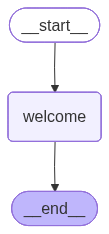

In [24]:
from IPython.display import Image,display
display(Image(final.get_graph().draw_mermaid_png()))

In [25]:
res=final.invoke({"message":"Kent"})

In [26]:
res

{'message': 'Hey Kent What is on your mind today'}

In [ ]:
from typing import TypedDict
from langgraph.graph import StateGraph

class AgentState(TypedDict):
    model:str
    
def armor(state:AgentState)->AgentState:
    """You are an description agent for the armors"""
    state["model"]="Hello sir "+state["model"] +" model is ready for test run"
    return state

ts=StateGraph(AgentState)
ts.add_node("Model_name",armor)
ts.set_entry_point("Model_name")
ts.set_finish_point("Model_name")
stark=ts.compile()

res=stark.invoke({"model":"Mark 70"})
res

{'model': 'Hello sir Mark 70 model is ready for test run'}

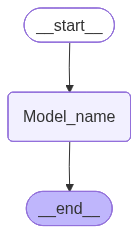

In [31]:
from IPython.display import Image,display
display(Image(stark.get_graph().draw_mermaid_png()))